In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [31]:
# ============================================================================
# 1. DATA PREPARATION
# ============================================================================

# Observed sequence
observations = np.array([134.3, 121.7,
114.1,
135.7,
133.9,
135.7,
146.5,
139.3,
133.2,
133.2,
126.0,
111.0,
110.0,
165.0,
154.0,
135.0,
154.0,
127.0,
171.0,
111.1,
138.6,
91.5,
144.1,
140.1,
140.3,
125.3,
117.2,
125.3,
133.3,
117.2,
120.0,
105.0,
93.0,
106.0,
99.7,
103.3,
101.6,
])
observations = np.ones(37)*10
n = len(observations)
X = np.array(np.arange(1,n+1))  # Draw numbers

print("=" * 60)
print("BAYESIAN SEQUENCE PREDICTION")
print("=" * 60)
print(f"\nObserved Data: {observations}")
print(f"Draw Numbers:  {X}")
print(f"Number of observations: {n}")

BAYESIAN SEQUENCE PREDICTION

Observed Data: [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10.]
Draw Numbers:  [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37]
Number of observations: 37


In [33]:
# ============================================================================
# 2. BAYESIAN LINEAR REGRESSION
# ============================================================================

print("\n" + "=" * 60)
print("BAYESIAN LINEAR REGRESSION")
print("=" * 60)

# Prior parameters (weakly informative)
mu_0 = 0        # Prior mean for slope
sigma_0_sq = 1000  # Prior variance for slope (large = uninformative)
alpha_0 = 0.01  # Prior shape parameter for noise precision
beta_0 = 0.01   # Prior rate parameter for noise precision

print(f"\nPrior Parameters:")
print(f"  Slope prior: N(μ₀={mu_0}, σ₀²={sigma_0_sq})")
print(f"  Noise precision prior: Gamma(α₀={alpha_0}, β₀={beta_0})")

# Calculate sufficient statistics
X_mean = np.mean(X)
y_mean = np.mean(observations)

X_centered = X - X_mean
y_centered = observations - y_mean

S_xx = np.sum(X_centered ** 2)
S_xy = np.sum(X_centered * y_centered)

print(f"\nSufficient Statistics:")
print(f"  S_xx (sum of squared deviations): {S_xx:.4f}")
print(f"  S_xy (sum of cross-products): {S_xy:.4f}")

# Maximum likelihood estimates
slope_mle = S_xy / S_xx
intercept_mle = y_mean - slope_mle * X_mean

print(f"\nMaximum Likelihood Estimates:")
print(f"  Slope (m): {slope_mle:.4f}")
print(f"  Intercept (b): {intercept_mle:.4f}")

# Calculate residuals
y_pred_train = intercept_mle + slope_mle * X
residuals = observations - y_pred_train
SSE = np.sum(residuals ** 2)

print(f"\nResiduals: {residuals}")
print(f"Sum of Squared Errors (SSE): {SSE:.4f}")

# Posterior parameters
sigma_n_sq = 1 / (1 / sigma_0_sq + S_xx)
mu_n = sigma_n_sq * (mu_0 / sigma_0_sq + S_xy)

alpha_n = alpha_0 + n / 2
beta_n = beta_0 + SSE / 2 + (slope_mle - mu_0) ** 2 / (2 * (sigma_0_sq + 1 / S_xx))

print(f"\nPosterior Parameters:")
print(f"  Slope posterior: N(μₙ={mu_n:.4f}, σₙ²={sigma_n_sq:.4f})")
print(f"  Noise precision posterior: Gamma(αₙ={alpha_n:.4f}, βₙ={beta_n:.4f})")


BAYESIAN LINEAR REGRESSION

Prior Parameters:
  Slope prior: N(μ₀=0, σ₀²=1000)
  Noise precision prior: Gamma(α₀=0.01, β₀=0.01)

Sufficient Statistics:
  S_xx (sum of squared deviations): 4218.0000
  S_xy (sum of cross-products): 0.0000

Maximum Likelihood Estimates:
  Slope (m): 0.0000
  Intercept (b): 10.0000

Residuals: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Sum of Squared Errors (SSE): 0.0000

Posterior Parameters:
  Slope posterior: N(μₙ=0.0000, σₙ²=0.0002)
  Noise precision posterior: Gamma(αₙ=18.5100, βₙ=0.0100)


In [17]:
# ============================================================================
# 3. PREDICTION FOR 4TH DRAW
# ============================================================================

print("\n" + "=" * 60)
print("PREDICTION FOR 4TH DRAW")
print("=" * 60)

x_new = 38
y_pred_mean = intercept_mle + slope_mle * x_new

# Predictive variance components
noise_var = beta_n / (alpha_n - 1)  # Expected noise variance
param_var = sigma_n_sq * x_new ** 2  # Parameter uncertainty
pred_var = noise_var + param_var
pred_std = np.sqrt(pred_var)

print(f"\nPoint Prediction for x={x_new}:")
print(f"  Mean: {y_pred_mean:.4f}")
print(f"  Standard Deviation: {pred_std:.4f}")

# Confidence intervals
ci_95 = [y_pred_mean - 1.96 * pred_std, y_pred_mean + 1.96 * pred_std]
ci_68 = [y_pred_mean - pred_std, y_pred_mean + pred_std]

print(f"\nUncertainty Quantification:")
print(f"  68% Credible Interval: [{ci_68[0]:.4f}, {ci_68[1]:.4f}]")
print(f"  95% Credible Interval: [{ci_95[0]:.4f}, {ci_95[1]:.4f}]")

print(f"\nVariance Decomposition:")
print(f"  Noise variance (aleatoric): {noise_var:.4f}")
print(f"  Parameter variance (epistemic): {param_var:.4f}")
print(f"  Total predictive variance: {pred_var:.4f}")


PREDICTION FOR 4TH DRAW

Point Prediction for x=38:
  Mean: 111.9333
  Standard Deviation: 17.3362

Uncertainty Quantification:
  68% Credible Interval: [94.5971, 129.2695]
  95% Credible Interval: [77.9544, 145.9123]

Variance Decomposition:
  Noise variance (aleatoric): 300.2018
  Parameter variance (epistemic): 0.3423
  Total predictive variance: 300.5442



GENERATING VISUALIZATIONS

Plot saved as 'bayesian_prediction.png'


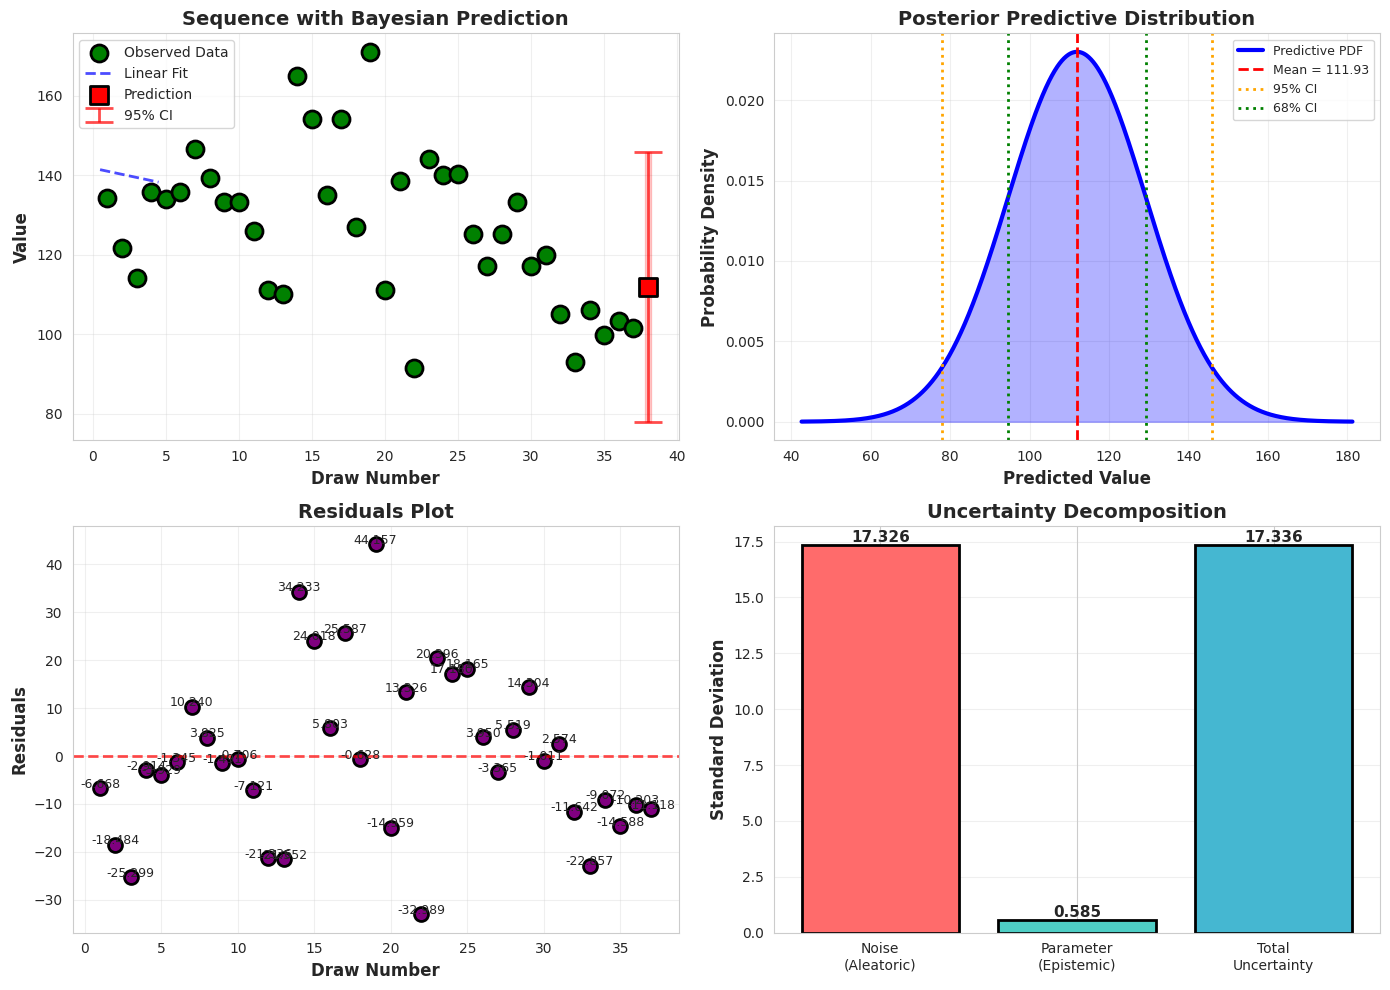

In [21]:
# ============================================================================
# 4. VISUALIZATION
# ============================================================================

print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Observed Data and Predictions ---
ax1 = axes[0, 0]
x_plot = np.linspace(0.5, 4.5, 100)
y_plot = intercept_mle + slope_mle * x_plot

ax1.scatter(X, observations, s=150, c='green', marker='o', 
            label='Observed Data', zorder=5, edgecolors='black', linewidth=2)
ax1.plot(x_plot, y_plot, 'b--', linewidth=2, label='Linear Fit', alpha=0.7)

# Prediction with uncertainty
ax1.scatter([x_new], [y_pred_mean], s=150, c='red', marker='s', 
            label='Prediction', zorder=5, edgecolors='black', linewidth=2)
ax1.errorbar([x_new], [y_pred_mean], yerr=[1.96 * pred_std], 
             fmt='none', c='red', capsize=10, capthick=2, linewidth=2, 
             label='95% CI', alpha=0.7)

ax1.fill_between([x_new - 0.2, x_new + 0.2], 
                 [ci_95[0], ci_95[0]], 
                 [ci_95[1], ci_95[1]], 
                 alpha=0.2, color='red')

ax1.set_xlabel('Draw Number', fontsize=12, fontweight='bold')
ax1.set_ylabel('Value', fontsize=12, fontweight='bold')
ax1.set_title('Sequence with Bayesian Prediction', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Posterior Predictive Distribution ---
ax2 = axes[0, 1]
x_dist = np.linspace(y_pred_mean - 4 * pred_std, y_pred_mean + 4 * pred_std, 1000)
pdf = stats.norm.pdf(x_dist, y_pred_mean, pred_std)

ax2.plot(x_dist, pdf, 'b-', linewidth=3, label='Predictive PDF')
ax2.fill_between(x_dist, 0, pdf, alpha=0.3, color='blue')

# Mark mean and confidence intervals
ax2.axvline(y_pred_mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {y_pred_mean:.2f}')
ax2.axvline(ci_95[0], color='orange', linestyle=':', linewidth=2, label='95% CI')
ax2.axvline(ci_95[1], color='orange', linestyle=':', linewidth=2)
ax2.axvline(ci_68[0], color='green', linestyle=':', linewidth=2, label='68% CI')
ax2.axvline(ci_68[1], color='green', linestyle=':', linewidth=2)

ax2.set_xlabel('Predicted Value', fontsize=12, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax2.set_title('Posterior Predictive Distribution', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# --- Plot 3: Residuals Analysis ---
ax3 = axes[1, 0]
ax3.scatter(X, residuals, s=100, c='purple', marker='o', edgecolors='black', linewidth=2)
ax3.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax3.set_xlabel('Draw Number', fontsize=12, fontweight='bold')
ax3.set_ylabel('Residuals', fontsize=12, fontweight='bold')
ax3.set_title('Residuals Plot', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add residual values as text
for i, (x, r) in enumerate(zip(X, residuals)):
    ax3.text(x, r + 0.1, f'{r:.3f}', ha='center', fontsize=9)

# --- Plot 4: Uncertainty Decomposition ---
ax4 = axes[1, 1]
uncertainty_components = {
    'Noise\n(Aleatoric)': np.sqrt(noise_var),
    'Parameter\n(Epistemic)': np.sqrt(param_var),
    'Total\nUncertainty': pred_std
}

bars = ax4.bar(uncertainty_components.keys(), uncertainty_components.values(), 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=2)

ax4.set_ylabel('Standard Deviation', fontsize=12, fontweight='bold')
ax4.set_title('Uncertainty Decomposition', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, uncertainty_components.values()):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('bayesian_prediction.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as 'bayesian_prediction.png'")
plt.show()


MONTE CARLO SAMPLING FROM POSTERIOR

Monte Carlo Statistics (n=10000 samples):
  Mean: 111.8179
  Std Dev: 17.3059
  95% Interval: [77.4694, 145.7534]
Plot saved as 'monte_carlo_comparison.png'


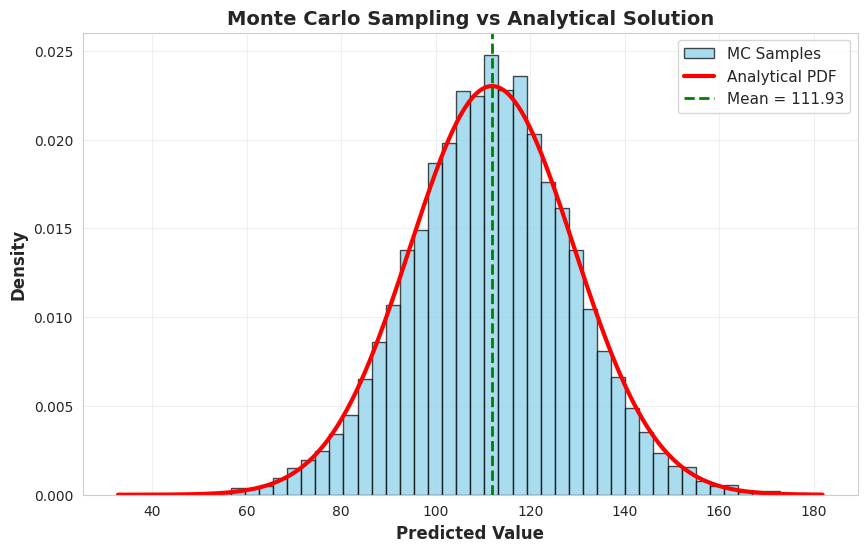

In [22]:
# ============================================================================
# 5. ADDITIONAL ANALYSIS: SAMPLING FROM POSTERIOR
# ============================================================================

print("\n" + "=" * 60)
print("MONTE CARLO SAMPLING FROM POSTERIOR")
print("=" * 60)

# Sample from posterior distribution
n_samples = 10000

# Sample slopes from posterior
slopes_posterior = np.random.normal(mu_n, np.sqrt(sigma_n_sq), n_samples)

# Sample noise variance
noise_precision_samples = np.random.gamma(alpha_n, 1/beta_n, n_samples)
noise_variance_samples = 1 / noise_precision_samples

# Generate predictions
predictions = []
for slope, noise_var in zip(slopes_posterior, noise_variance_samples):
    y_pred = intercept_mle + slope * x_new
    y_pred_noisy = np.random.normal(y_pred, np.sqrt(noise_var))
    predictions.append(y_pred_noisy)

predictions = np.array(predictions)

print(f"\nMonte Carlo Statistics (n={n_samples} samples):")
print(f"  Mean: {np.mean(predictions):.4f}")
print(f"  Std Dev: {np.std(predictions):.4f}")
print(f"  95% Interval: [{np.percentile(predictions, 2.5):.4f}, {np.percentile(predictions, 97.5):.4f}]")

# Plot histogram of samples
plt.figure(figsize=(10, 6))
plt.hist(predictions, bins=50, density=True, alpha=0.7, color='skyblue', 
         edgecolor='black', label='MC Samples')

# Overlay analytical solution
x_dist = np.linspace(predictions.min(), predictions.max(), 1000)
pdf = stats.norm.pdf(x_dist, y_pred_mean, pred_std)
plt.plot(x_dist, pdf, 'r-', linewidth=3, label='Analytical PDF')

plt.axvline(y_pred_mean, color='green', linestyle='--', linewidth=2, 
            label=f'Mean = {y_pred_mean:.2f}')
plt.xlabel('Predicted Value', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')
plt.title('Monte Carlo Sampling vs Analytical Solution', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('monte_carlo_comparison.png', dpi=300, bbox_inches='tight')
print("Plot saved as 'monte_carlo_comparison.png'")
plt.show()


In [23]:
# ============================================================================
# 6. SUMMARY TABLE
# ============================================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

summary = f"""
╔═══════════════════════════════════════════════════════════╗
║           BAYESIAN PREDICTION SUMMARY                     ║
╠═══════════════════════════════════════════════════════════╣
║ Observed Sequence:    {observations[0]}, {observations[1]}, {observations[2]}                          ║
║ Model:                Linear (y = mx + b + ε)             ║
║                                                           ║
║ ESTIMATED PARAMETERS:                                     ║
║   Slope (m):          {slope_mle:>8.4f}                          ║
║   Intercept (b):      {intercept_mle:>8.4f}                          ║
║                                                           ║
║ PREDICTION FOR 4TH DRAW:                                  ║
║   Point Estimate:     {y_pred_mean:>8.4f}                          ║
║   Uncertainty (±σ):   {pred_std:>8.4f}                          ║
║   68% Interval:       [{ci_68[0]:>6.2f}, {ci_68[1]:>6.2f}]              ║
║   95% Interval:       [{ci_95[0]:>6.2f}, {ci_95[1]:>6.2f}]              ║
║                                                           ║
║ UNCERTAINTY BREAKDOWN:                                    ║
║   Aleatoric (noise):  {np.sqrt(noise_var):>8.4f}                          ║
║   Epistemic (params): {np.sqrt(param_var):>8.4f}                          ║
╚═══════════════════════════════════════════════════════════╝
"""

print(summary)

print("\n✓ Analysis complete!")
print("✓ Check the generated plots for visualizations")


FINAL SUMMARY

╔═══════════════════════════════════════════════════════════╗
║           BAYESIAN PREDICTION SUMMARY                     ║
╠═══════════════════════════════════════════════════════════╣
║ Observed Sequence:    134.3, 121.7, 114.1                          ║
║ Model:                Linear (y = mx + b + ε)             ║
║                                                           ║
║ ESTIMATED PARAMETERS:                                     ║
║   Slope (m):           -0.7847                          ║
║   Intercept (b):      141.7532                          ║
║                                                           ║
║ PREDICTION FOR 4TH DRAW:                                  ║
║   Point Estimate:     111.9333                          ║
║   Uncertainty (±σ):    17.3362                          ║
║   68% Interval:       [ 94.60, 129.27]              ║
║   95% Interval:       [ 77.95, 145.91]              ║
║                                                           ║
║ U

In [34]:
# ============================================================================
# 3. PREDICT NEXT 10 DRAWS (38-47)
# ============================================================================

print("\n" + "=" * 70)
print("PREDICTIONS FOR DRAWS 38-47")
print("=" * 70)

# Future draw numbers
X_future = np.arange(38, 48)  # [38, 39, 40, ..., 47]

# Predictions with uncertainty
predictions = []
uncertainties = []
ci_95_lower = []
ci_95_upper = []
ci_68_lower = []
ci_68_upper = []

for x_new in X_future:
    # Mean prediction
    y_pred_mean = intercept_mle + slope_mle * x_new
    
    # Predictive variance
    # Note: variance increases with distance from observed data
    x_new_centered = x_new - X_mean
    param_var = sigma_n_sq * (1 + x_new_centered**2 / S_xx)
    pred_var = noise_var + param_var
    pred_std = np.sqrt(pred_var)
    
    predictions.append(y_pred_mean)
    uncertainties.append(pred_std)
    ci_95_lower.append(y_pred_mean - 1.96 * pred_std)
    ci_95_upper.append(y_pred_mean + 1.96 * pred_std)
    ci_68_lower.append(y_pred_mean - pred_std)
    ci_68_upper.append(y_pred_mean + pred_std)

predictions = np.array(predictions)
uncertainties = np.array(uncertainties)
ci_95_lower = np.array(ci_95_lower)
ci_95_upper = np.array(ci_95_upper)
ci_68_lower = np.array(ci_68_lower)
ci_68_upper = np.array(ci_68_upper)

# Print predictions
print("\n{:<8} {:<12} {:<12} {:<25}".format("Draw", "Prediction", "Std Dev", "95% Interval"))
print("-" * 70)
for i, x in enumerate(X_future):
    print("{:<8} {:<12.2f} {:<12.2f} [{:.2f}, {:.2f}]".format(
        x, predictions[i], uncertainties[i], ci_95_lower[i], ci_95_upper[i]
    ))


PREDICTIONS FOR DRAWS 38-47

Draw     Prediction   Std Dev      95% Interval             
----------------------------------------------------------------------
38       10.00        14.45        [-18.33, 38.33]
39       10.00        14.45        [-18.33, 38.33]
40       10.00        14.45        [-18.33, 38.33]
41       10.00        14.45        [-18.33, 38.33]
42       10.00        14.45        [-18.33, 38.33]
43       10.00        14.45        [-18.33, 38.33]
44       10.00        14.45        [-18.33, 38.33]
45       10.00        14.45        [-18.33, 38.33]
46       10.00        14.45        [-18.33, 38.33]
47       10.00        14.45        [-18.33, 38.33]



GENERATING VISUALIZATION

✓ Main plot saved as 'bayesian_37_draws_prediction.png'


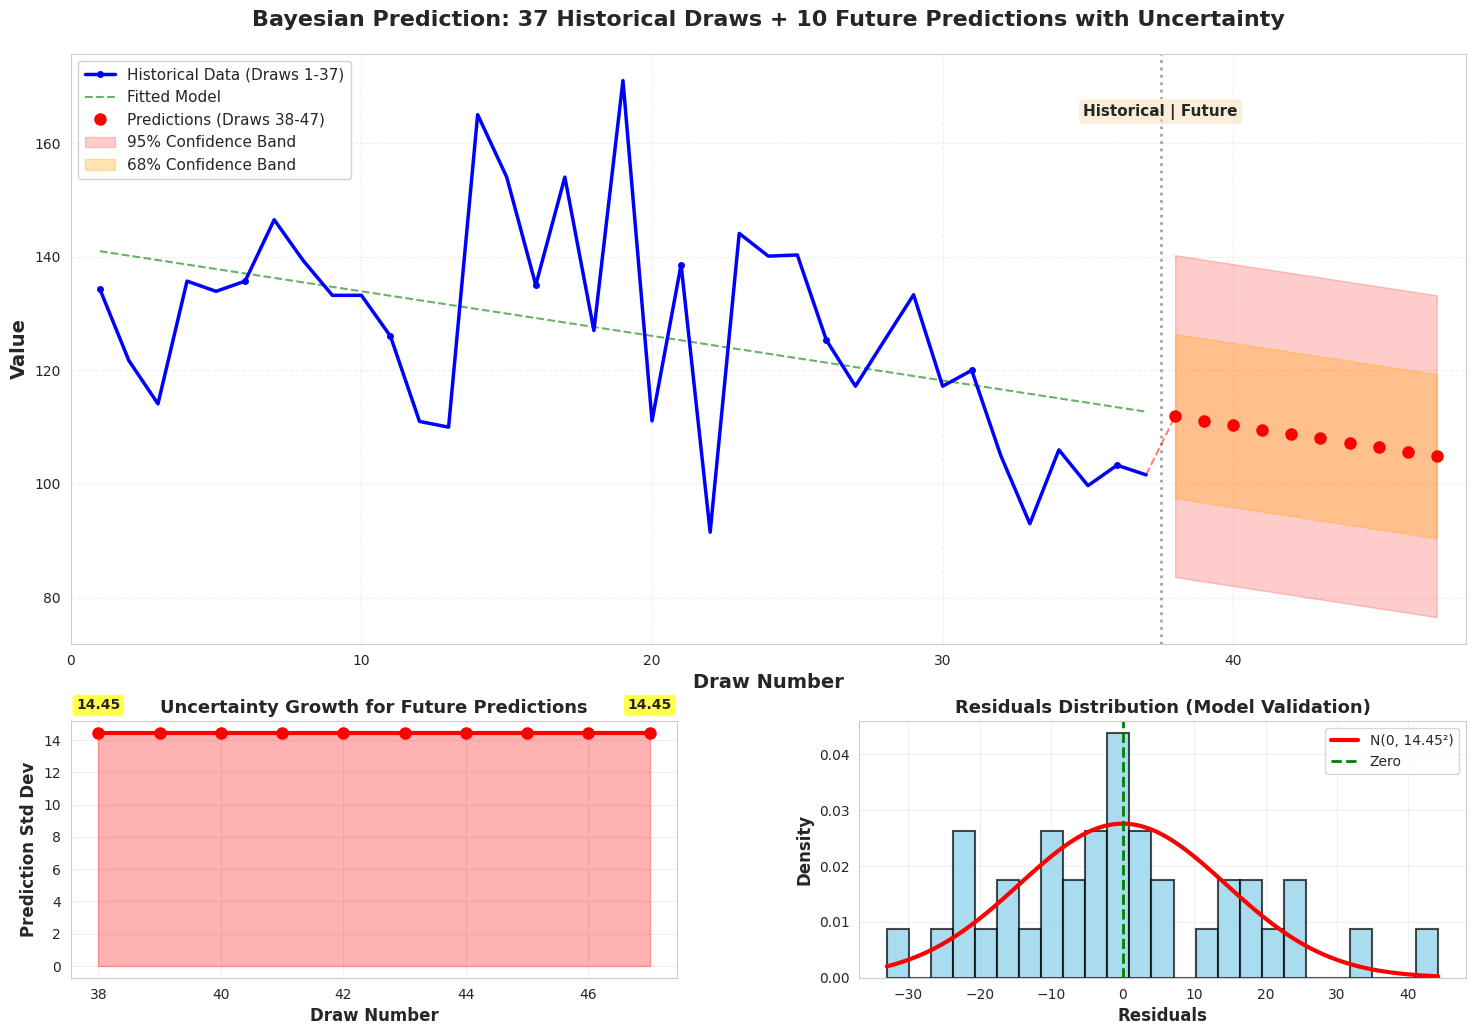

In [25]:
# ============================================================================
# 4. COMPREHENSIVE VISUALIZATION
# ============================================================================

print("\n" + "=" * 70)
print("GENERATING VISUALIZATION")
print("=" * 70)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# --- MAIN PLOT: Historical Data + Future Predictions with Uncertainty Bands ---
ax_main = fig.add_subplot(gs[0:2, :])

# Plot historical data (draws 1-37) as line plot
ax_main.plot(X, observations, 'b-', linewidth=2.5, label='Historical Data (Draws 1-37)', 
             marker='o', markersize=4, markevery=5, zorder=3)

# Plot fitted line through historical data
ax_main.plot(X, y_pred_train, 'g--', linewidth=1.5, alpha=0.6, 
             label='Fitted Model', zorder=2)

# Plot future predictions (draws 38-47) as points
ax_main.plot(X_future, predictions, 'ro', markersize=8, 
             label='Predictions (Draws 38-47)', zorder=5)

# Connect last historical point to first prediction
ax_main.plot([X[-1], X_future[0]], [observations[-1], predictions[0]], 
             'r--', linewidth=1.5, alpha=0.5, zorder=2)

# Add uncertainty bands for future predictions
ax_main.fill_between(X_future, ci_95_lower, ci_95_upper, 
                      alpha=0.2, color='red', label='95% Confidence Band', zorder=1)
ax_main.fill_between(X_future, ci_68_lower, ci_68_upper, 
                      alpha=0.3, color='orange', label='68% Confidence Band', zorder=1)

# Visual separator between historical and future
ax_main.axvline(x=37.5, color='gray', linestyle=':', linewidth=2, alpha=0.7, zorder=1)
ax_main.text(37.5, ax_main.get_ylim()[1] * 0.95, 'Historical | Future', 
             ha='center', va='top', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax_main.set_xlabel('Draw Number', fontsize=14, fontweight='bold')
ax_main.set_ylabel('Value', fontsize=14, fontweight='bold')
ax_main.set_title('Bayesian Prediction: 37 Historical Draws + 10 Future Predictions with Uncertainty', 
                  fontsize=16, fontweight='bold', pad=20)
ax_main.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax_main.grid(True, alpha=0.3, linestyle='--')
ax_main.set_xlim(0, 48)

# --- SUBPLOT 1: Uncertainty Growth ---
ax1 = fig.add_subplot(gs[2, 0])
ax1.plot(X_future, uncertainties, 'r-', linewidth=3, marker='o', markersize=8)
ax1.fill_between(X_future, 0, uncertainties, alpha=0.3, color='red')
ax1.set_xlabel('Draw Number', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prediction Std Dev', fontsize=12, fontweight='bold')
ax1.set_title('Uncertainty Growth for Future Predictions', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Annotate first and last uncertainty
ax1.annotate(f'{uncertainties[0]:.2f}', xy=(X_future[0], uncertainties[0]), 
             xytext=(X_future[0], uncertainties[0] + uncertainties.max() * 0.1),
             ha='center', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
ax1.annotate(f'{uncertainties[-1]:.2f}', xy=(X_future[-1], uncertainties[-1]), 
             xytext=(X_future[-1], uncertainties[-1] + uncertainties.max() * 0.1),
             ha='center', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# --- SUBPLOT 2: Residuals Distribution ---
ax2 = fig.add_subplot(gs[2, 1])
ax2.hist(residuals, bins=25, density=True, alpha=0.7, color='skyblue', 
         edgecolor='black', linewidth=1.5)

# Overlay normal distribution
x_resid = np.linspace(residuals.min(), residuals.max(), 100)
ax2.plot(x_resid, stats.norm.pdf(x_resid, 0, np.sqrt(noise_var)), 
         'r-', linewidth=3, label=f'N(0, {np.sqrt(noise_var):.2f}²)')

ax2.axvline(0, color='green', linestyle='--', linewidth=2, label='Zero')
ax2.set_xlabel('Residuals', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('Residuals Distribution (Model Validation)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.savefig('bayesian_37_draws_prediction.png', dpi=300, bbox_inches='tight')
print("\n✓ Main plot saved as 'bayesian_37_draws_prediction.png'")
plt.show()

✓ Detailed plot saved as 'bayesian_detailed_future.png'


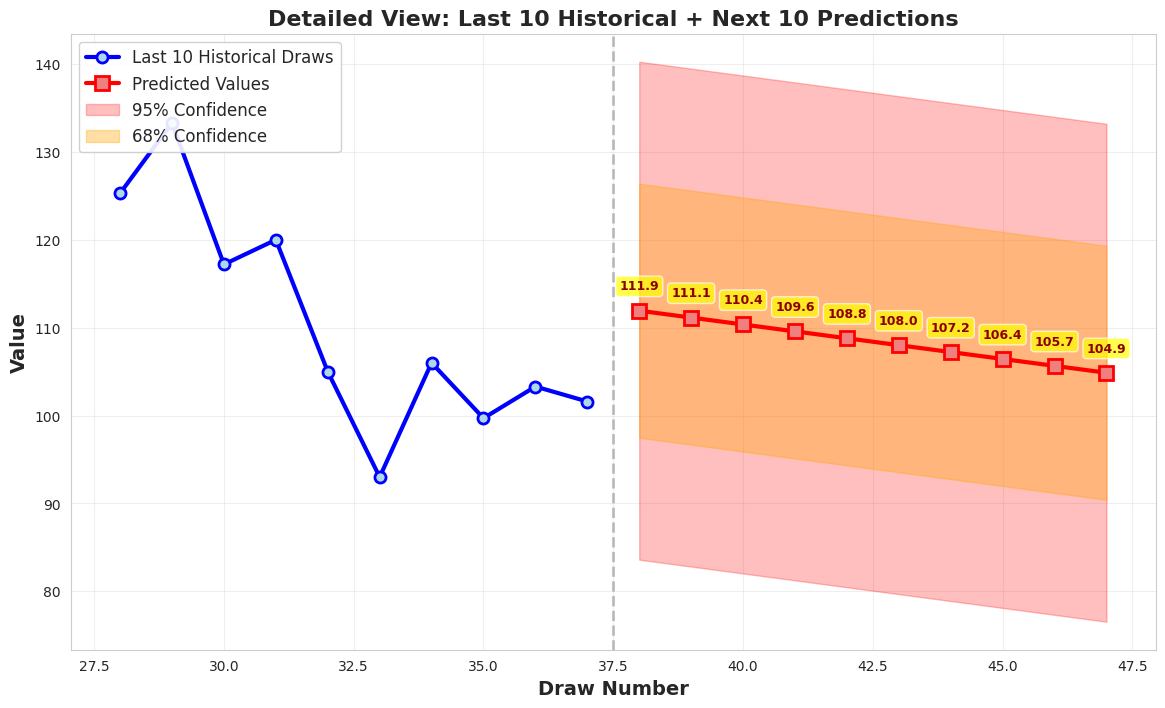

In [26]:
# ============================================================================
# 5. DETAILED PREDICTION PLOT (Zoomed on Future)
# ============================================================================

fig2, ax = plt.subplots(figsize=(14, 8))

# Show last 10 historical points for context
context_start = max(0, n - 10)
X_context = X[context_start:]
y_context = observations[context_start:]

ax.plot(X_context, y_context, 'b-', linewidth=3, marker='o', markersize=8,
        label='Last 10 Historical Draws', markerfacecolor='lightblue', 
        markeredgecolor='blue', markeredgewidth=2)

# Future predictions
ax.plot(X_future, predictions, 'r-', linewidth=3, marker='s', markersize=10,
        label='Predicted Values', markerfacecolor='lightcoral', 
        markeredgecolor='red', markeredgewidth=2)

# Uncertainty bands
ax.fill_between(X_future, ci_95_lower, ci_95_upper, 
                alpha=0.25, color='red', label='95% Confidence')
ax.fill_between(X_future, ci_68_lower, ci_68_upper, 
                alpha=0.35, color='orange', label='68% Confidence')

# Add value labels on predictions
for i, (x, y) in enumerate(zip(X_future, predictions)):
    ax.annotate(f'{y:.1f}', xy=(x, y), xytext=(0, 15),
                textcoords='offset points', ha='center', fontsize=9,
                fontweight='bold', color='darkred',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.axvline(x=37.5, color='gray', linestyle='--', linewidth=2, alpha=0.5)
ax.set_xlabel('Draw Number', fontsize=14, fontweight='bold')
ax.set_ylabel('Value', fontsize=14, fontweight='bold')
ax.set_title('Detailed View: Last 10 Historical + Next 10 Predictions', 
             fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.savefig('bayesian_detailed_future.png', dpi=300, bbox_inches='tight')
print("✓ Detailed plot saved as 'bayesian_detailed_future.png'")
plt.show()